In [1]:
from utils import process_remote
from preparation import slice_by_dates, merge_datasets, smooth_data, handle_missing_values
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import zscore

In [2]:
terra_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv',
    duplicates=True, reindex=True,
    outliers=True, z_thresh=3,
    stats=False,
    filter_cols=False,
    interpolation=False,
    smooth=False
)
aqua_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_MA_500m_2002-07_2026-06.csv',
    duplicates=True, reindex=False,
    outliers=True, z_thresh=3,
    stats=False,
    filter_cols=False,
    interpolation=False,
    smooth=False
)
landsat_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv',
    duplicates=True, reindex=True,
    outliers=True, z_thresh=2.5,
    stats=True,
    filter_cols=True,
    remote_cols=['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean'],
    interpolation=False,
    smooth=False
)

In [3]:
start = '2023-01'
end = '2023-06'

In [4]:
modis_df1 = terra_df1.join(aqua_df1, how='outer', lsuffix='_terra', rsuffix='_aqua')
modis_df1 = slice_by_dates(modis_df1, start, end)

Sensor and solar zenith angle

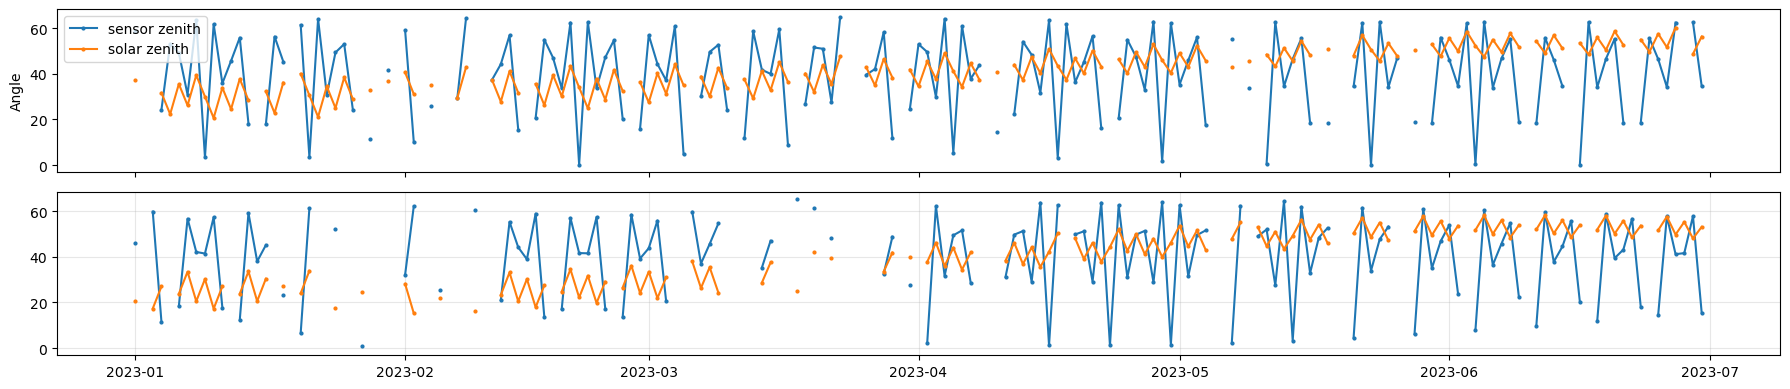

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 4), sharex=True, sharey=True)

ax1.plot(modis_df1.index, modis_df1['sensor_zenith_terra'], label='sensor zenith', marker='o', markersize=2)
ax1.plot(modis_df1.index, modis_df1['solar_zenith_terra'], label='solar zenith', marker='o', markersize=2)
ax1.set_ylabel('Angle')
ax1.legend(loc='upper left')

ax2.plot(modis_df1.index, modis_df1['sensor_zenith_aqua'], label='sensor zenith', marker='o', markersize=2)
ax2.plot(modis_df1.index, modis_df1['solar_zenith_aqua'], label='solar zenith', marker='o', markersize=2)

plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

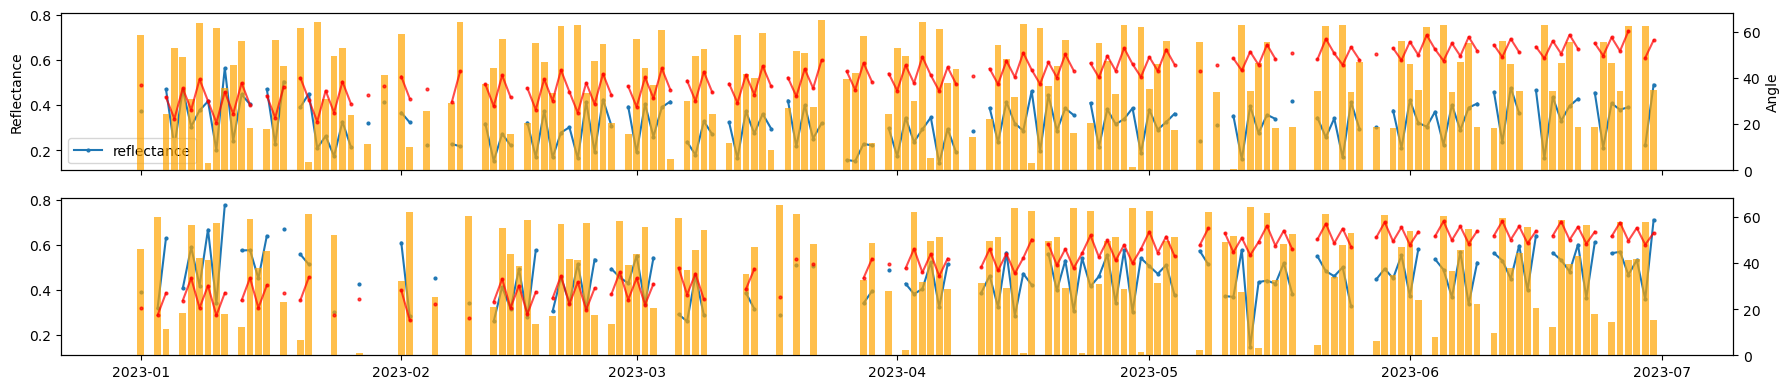

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 4), sharex=True, sharey=True)

ax1.plot(modis_df1.index, modis_df1['green_terra'], label='reflectance', marker='o', markersize=2)
ax3 = ax1.twinx()
ax3.bar(modis_df1.index, modis_df1['sensor_zenith_terra'], label='sensor angle', alpha=0.7, color='orange')
ax3.plot(modis_df1.index, modis_df1['solar_zenith_terra'], label='solar angle', alpha=0.7, color='red', marker='o', markersize=2)

ax2.plot(modis_df1.index, modis_df1['nir_aqua'], label='', marker='o', markersize=2)
ax4 = ax2.twinx()
ax4.bar(modis_df1.index, modis_df1['sensor_zenith_aqua'], label='', alpha=0.7, color='orange')
ax4.plot(modis_df1.index, modis_df1['solar_zenith_aqua'], label='', alpha=0.7, color='red', marker='o', markersize=2)

ax1.set_ylabel('Reflectance')
ax3.set_ylabel('Angle')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

Sensor and solar zenith angle standarized

In [7]:
z_modis_df1 = modis_df1.apply(zscore, nan_policy='omit')
z_modis_df1 = slice_by_dates(z_modis_df1, '2023-03', '2023-04')

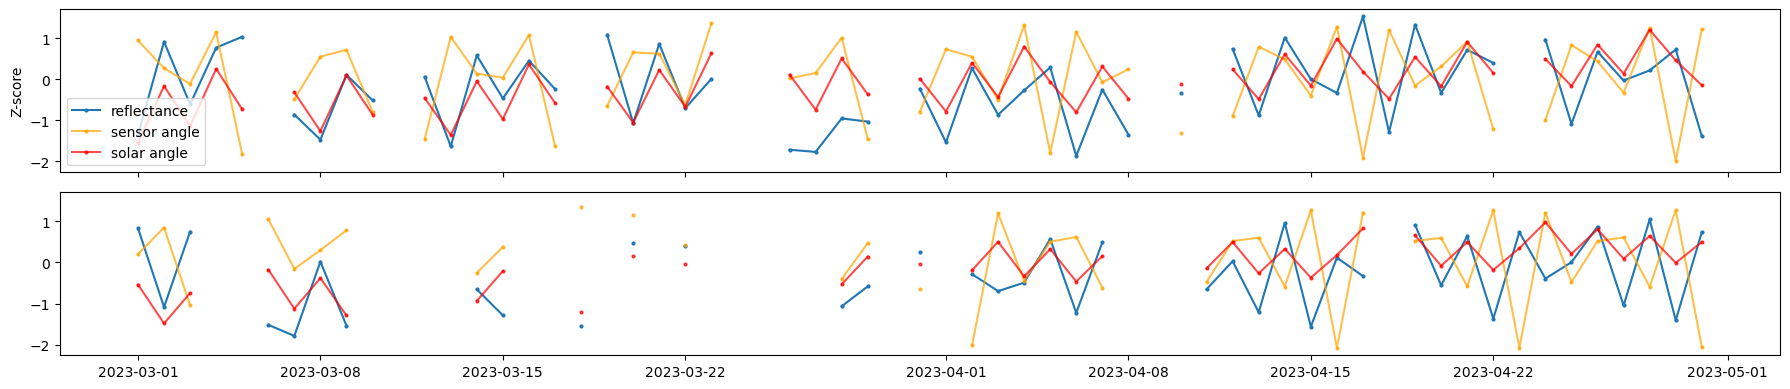

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 4), sharex=True, sharey=True)

ax1.plot(z_modis_df1.index, z_modis_df1['green_terra'], label='reflectance', marker='o', markersize=2)
#ax3 = ax1.twinx()
ax1.plot(z_modis_df1.index, z_modis_df1['sensor_zenith_terra'], label='sensor angle', alpha=0.7, color='orange', marker='o', markersize=2)
ax1.plot(z_modis_df1.index, z_modis_df1['solar_zenith_terra'], label='solar angle', alpha=0.7, color='red', marker='o', markersize=2)

ax2.plot(z_modis_df1.index, z_modis_df1['nir_aqua'], label='', marker='o', markersize=2)
#ax4 = ax2.twinx()
ax2.plot(z_modis_df1.index, z_modis_df1['sensor_zenith_aqua'], label='', alpha=0.7, color='orange',  marker='o', markersize=2)
ax2.plot(z_modis_df1.index, z_modis_df1['solar_zenith_aqua'], label='', alpha=0.7, color='red', marker='o', markersize=2)

ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

Smoothed modis

In [20]:
interpolated_modis_df1 = modis_df1.interpolate(method='time')
interpolated_modis_df1 = interpolated_modis_df1.dropna()
interpolated_modis_df1.isna().sum()
smooth_modis_df1 = smooth_data(interpolated_modis_df1, None, 25, 2)

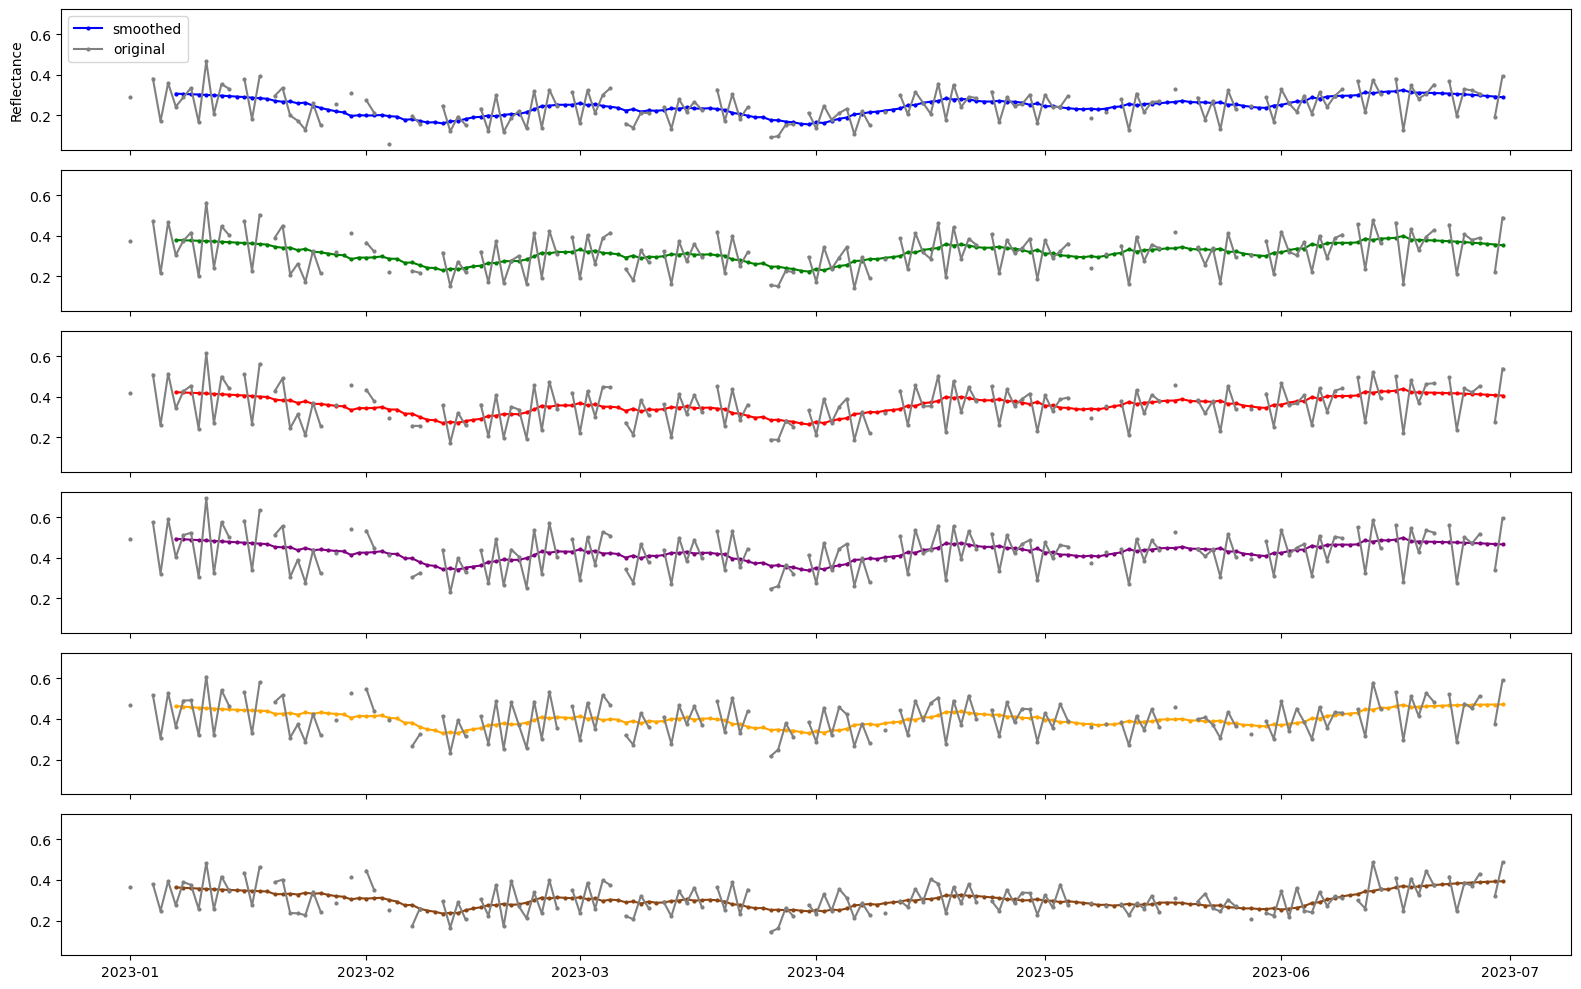

In [21]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(smooth_modis_df1.index, smooth_modis_df1['blue_terra'], label='smoothed', c='blue', marker='o', markersize=2)
ax1.plot(modis_df1.index, modis_df1['blue_terra'], label='original', color='gray', marker='o', markersize=2)
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(smooth_modis_df1.index, smooth_modis_df1['green_terra'], c='green', marker='o', markersize=2)
ax2.plot(modis_df1.index, modis_df1['green_terra'], color='gray', marker='o', markersize=2)

ax3.plot(smooth_modis_df1.index, smooth_modis_df1['red_terra'], c='red', marker='o', markersize=2)
ax3.plot(modis_df1.index, modis_df1['red_terra'], color='gray', marker='o', markersize=2)

ax4.plot(smooth_modis_df1.index, smooth_modis_df1['nir_terra'], c='purple', marker='o', markersize=2)
ax4.plot(modis_df1.index, modis_df1['nir_terra'], color='gray', marker='o', markersize=2)

ax5.plot(smooth_modis_df1.index, smooth_modis_df1['swir1_terra'], c='orange', marker='o', markersize=2)
ax5.plot(modis_df1.index, modis_df1['swir1_terra'], color='gray', marker='o', markersize=2)

ax6.plot(smooth_modis_df1.index, smooth_modis_df1['swir2_terra'], c='saddlebrown', marker='o', markersize=2)
ax6.plot(modis_df1.index, modis_df1['swir2_terra'], color='gray', marker='o', markersize=2)

plt.tight_layout()
plt.show()

Terra vs Aqua

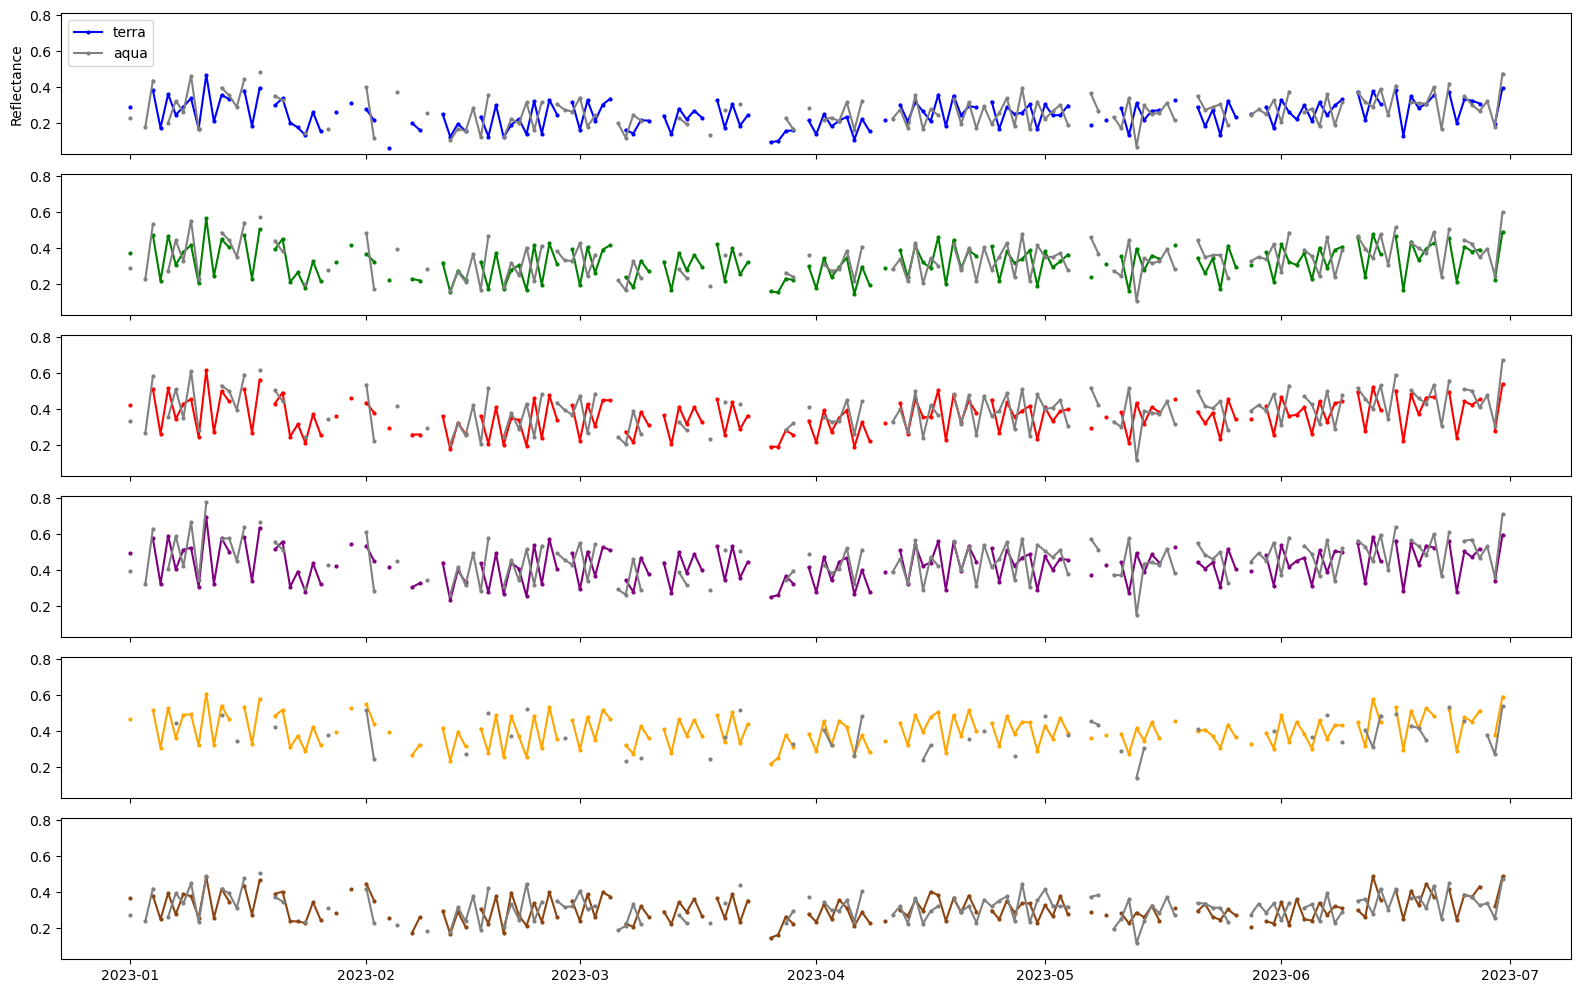

In [22]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(modis_df1.index, modis_df1['blue_terra'], label='terra', c='blue', marker='o', markersize=2)
ax1.plot(modis_df1.index, modis_df1['blue_aqua'], label='aqua', color='gray', marker='o', markersize=2)
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(modis_df1.index, modis_df1['green_terra'], c='green', marker='o', markersize=2)
ax2.plot(modis_df1.index, modis_df1['green_aqua'], color='gray', marker='o', markersize=2)

ax3.plot(modis_df1.index, modis_df1['red_terra'], c='red', marker='o', markersize=2)
ax3.plot(modis_df1.index, modis_df1['red_aqua'], color='gray', marker='o', markersize=2)

ax4.plot(modis_df1.index, modis_df1['nir_terra'], c='purple', marker='o', markersize=2)
ax4.plot(modis_df1.index, modis_df1['nir_aqua'], color='gray', marker='o', markersize=2)

ax5.plot(modis_df1.index, modis_df1['swir1_terra'], c='orange', marker='o', markersize=2)
ax5.plot(modis_df1.index, modis_df1['swir1_aqua'], color='gray', marker='o', markersize=2)

ax6.plot(modis_df1.index, modis_df1['swir2_terra'], c='saddlebrown', marker='o', markersize=2)
ax6.plot(modis_df1.index, modis_df1['swir2_aqua'], color='gray', marker='o', markersize=2)

plt.tight_layout()
plt.show()

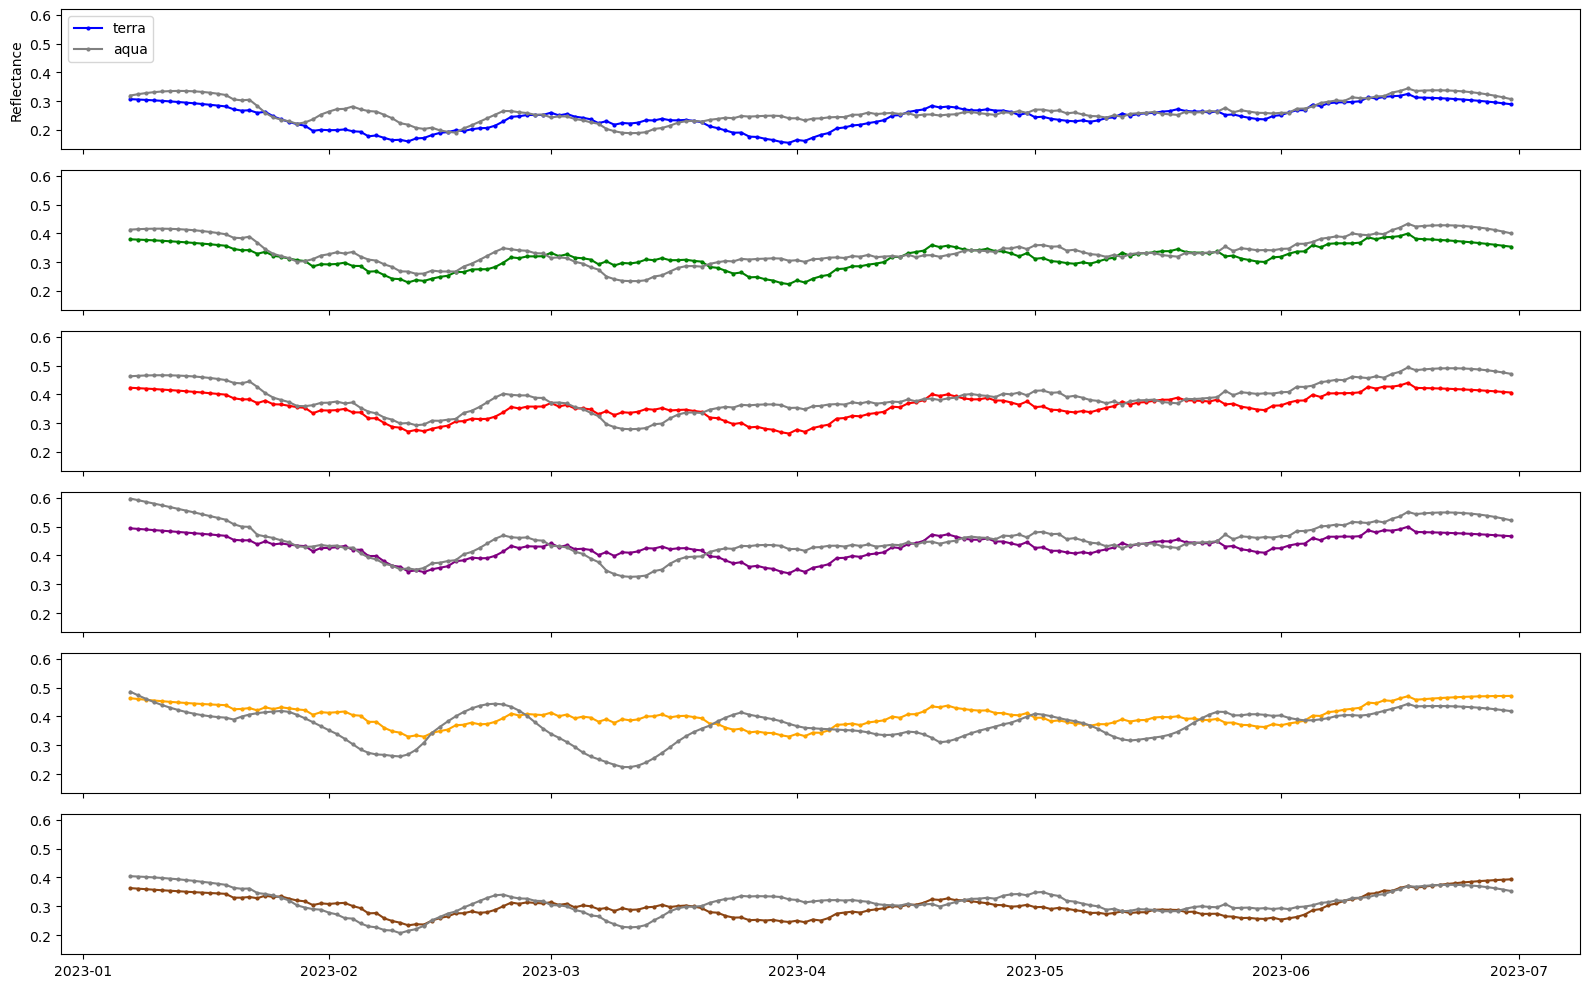

In [23]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(smooth_modis_df1.index, smooth_modis_df1['blue_terra'], label='terra', c='blue', marker='o', markersize=2)
ax1.plot(smooth_modis_df1.index, smooth_modis_df1['blue_aqua'], label='aqua', color='gray', marker='o', markersize=2)
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(smooth_modis_df1.index, smooth_modis_df1['green_terra'], c='green', marker='o', markersize=2)
ax2.plot(smooth_modis_df1.index, smooth_modis_df1['green_aqua'], color='gray', marker='o', markersize=2)

ax3.plot(smooth_modis_df1.index, smooth_modis_df1['red_terra'], c='red', marker='o', markersize=2)
ax3.plot(smooth_modis_df1.index, smooth_modis_df1['red_aqua'], color='gray', marker='o', markersize=2)

ax4.plot(smooth_modis_df1.index, smooth_modis_df1['nir_terra'], c='purple', marker='o', markersize=2)
ax4.plot(smooth_modis_df1.index, smooth_modis_df1['nir_aqua'], color='gray', marker='o', markersize=2)

ax5.plot(smooth_modis_df1.index, smooth_modis_df1['swir1_terra'], c='orange', marker='o', markersize=2)
ax5.plot(smooth_modis_df1.index, smooth_modis_df1['swir1_aqua'], color='gray', marker='o', markersize=2)

ax6.plot(smooth_modis_df1.index, smooth_modis_df1['swir2_terra'], c='saddlebrown', marker='o', markersize=2)
ax6.plot(smooth_modis_df1.index, smooth_modis_df1['swir2_aqua'], color='gray', marker='o', markersize=2)

plt.tight_layout()
plt.show()

Modis vs landsat

In [24]:
modis_landsat_df1 = merge_datasets(smooth_modis_df1, landsat_df1)
modis_landsat_df1 = slice_by_dates(modis_landsat_df1, start, end)

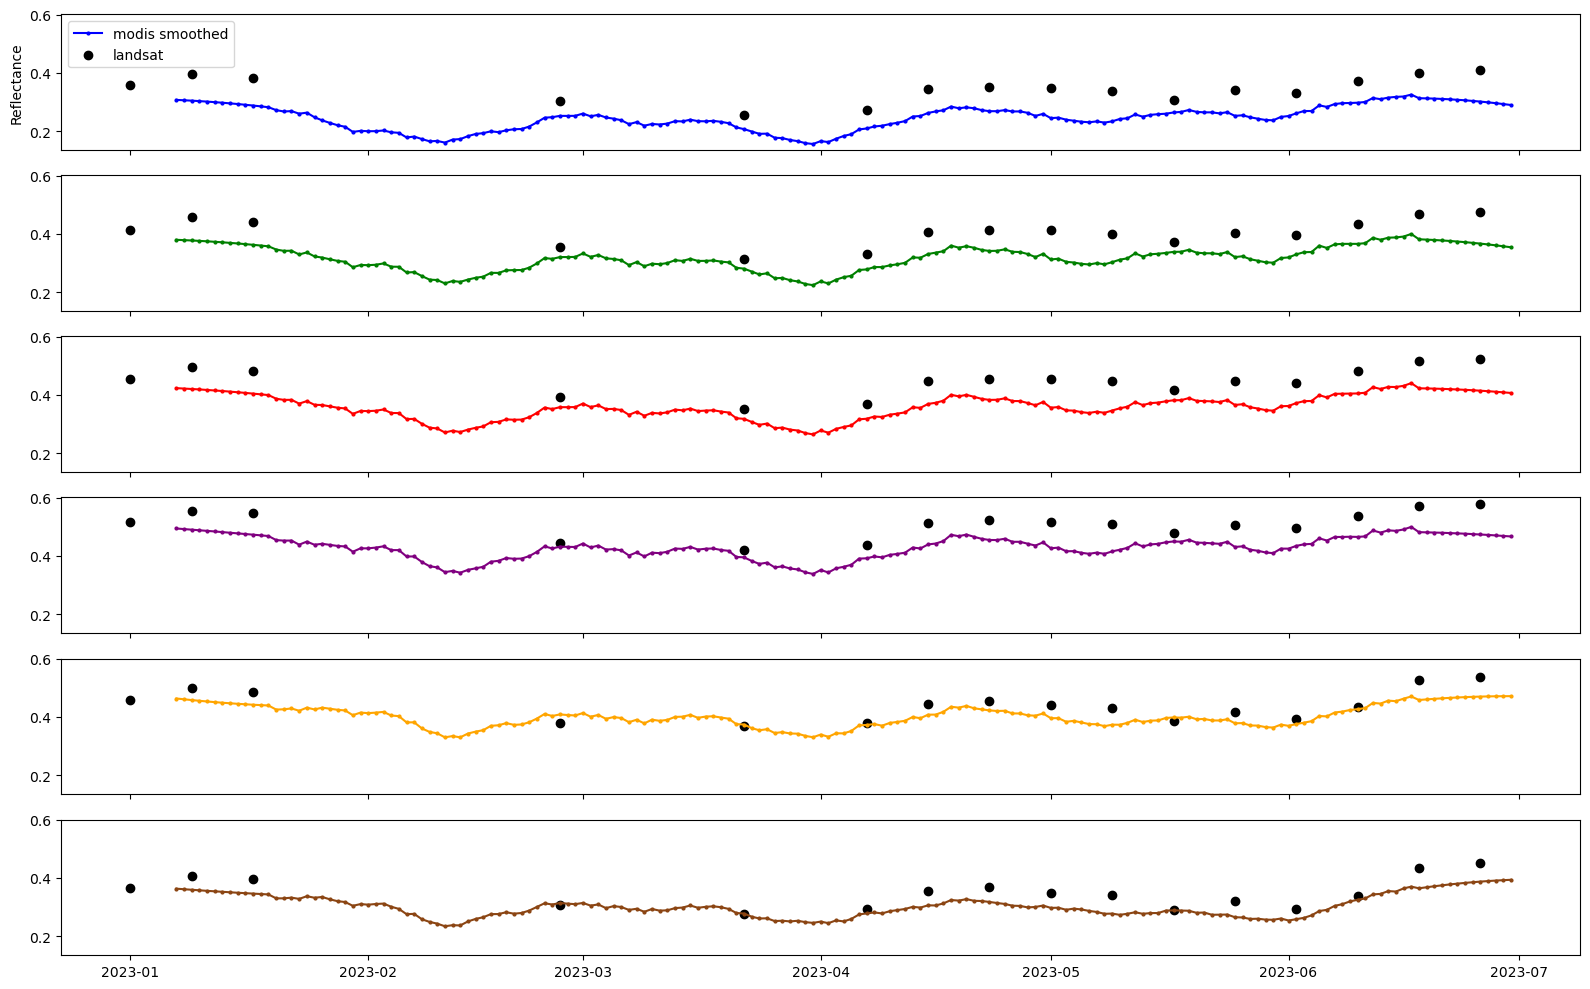

In [25]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(modis_landsat_df1.index, modis_landsat_df1['blue_terra'], label='modis smoothed', c='blue', marker='o', markersize=2)
ax1.scatter(modis_landsat_df1.index, modis_landsat_df1['blue_mean'], label='landsat', color='black')
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(modis_landsat_df1.index, modis_landsat_df1['green_terra'], c='green', marker='o', markersize=2)
ax2.scatter(modis_landsat_df1.index, modis_landsat_df1['green_mean'], color='black')

ax3.plot(modis_landsat_df1.index, modis_landsat_df1['red_terra'], c='red', marker='o', markersize=2)
ax3.scatter(modis_landsat_df1.index, modis_landsat_df1['red_mean'], color='black')

ax4.plot(modis_landsat_df1.index, modis_landsat_df1['nir_terra'], c='purple', marker='o', markersize=2)
ax4.scatter(modis_landsat_df1.index, modis_landsat_df1['nir_mean'], color='black')

ax5.plot(modis_landsat_df1.index, modis_landsat_df1['swir1_terra'], c='orange', marker='o', markersize=2)
ax5.scatter(modis_landsat_df1.index, modis_landsat_df1['swir1_mean'], color='black')

ax6.plot(modis_landsat_df1.index, modis_landsat_df1['swir2_terra'], c='saddlebrown', marker='o', markersize=2)
ax6.scatter(modis_landsat_df1.index, modis_landsat_df1['swir2_mean'], color='black')

plt.tight_layout()
plt.show()

In [26]:
fused = merge_datasets(terra_df1, landsat_df1)
fused = slice_by_dates(fused, start, end)

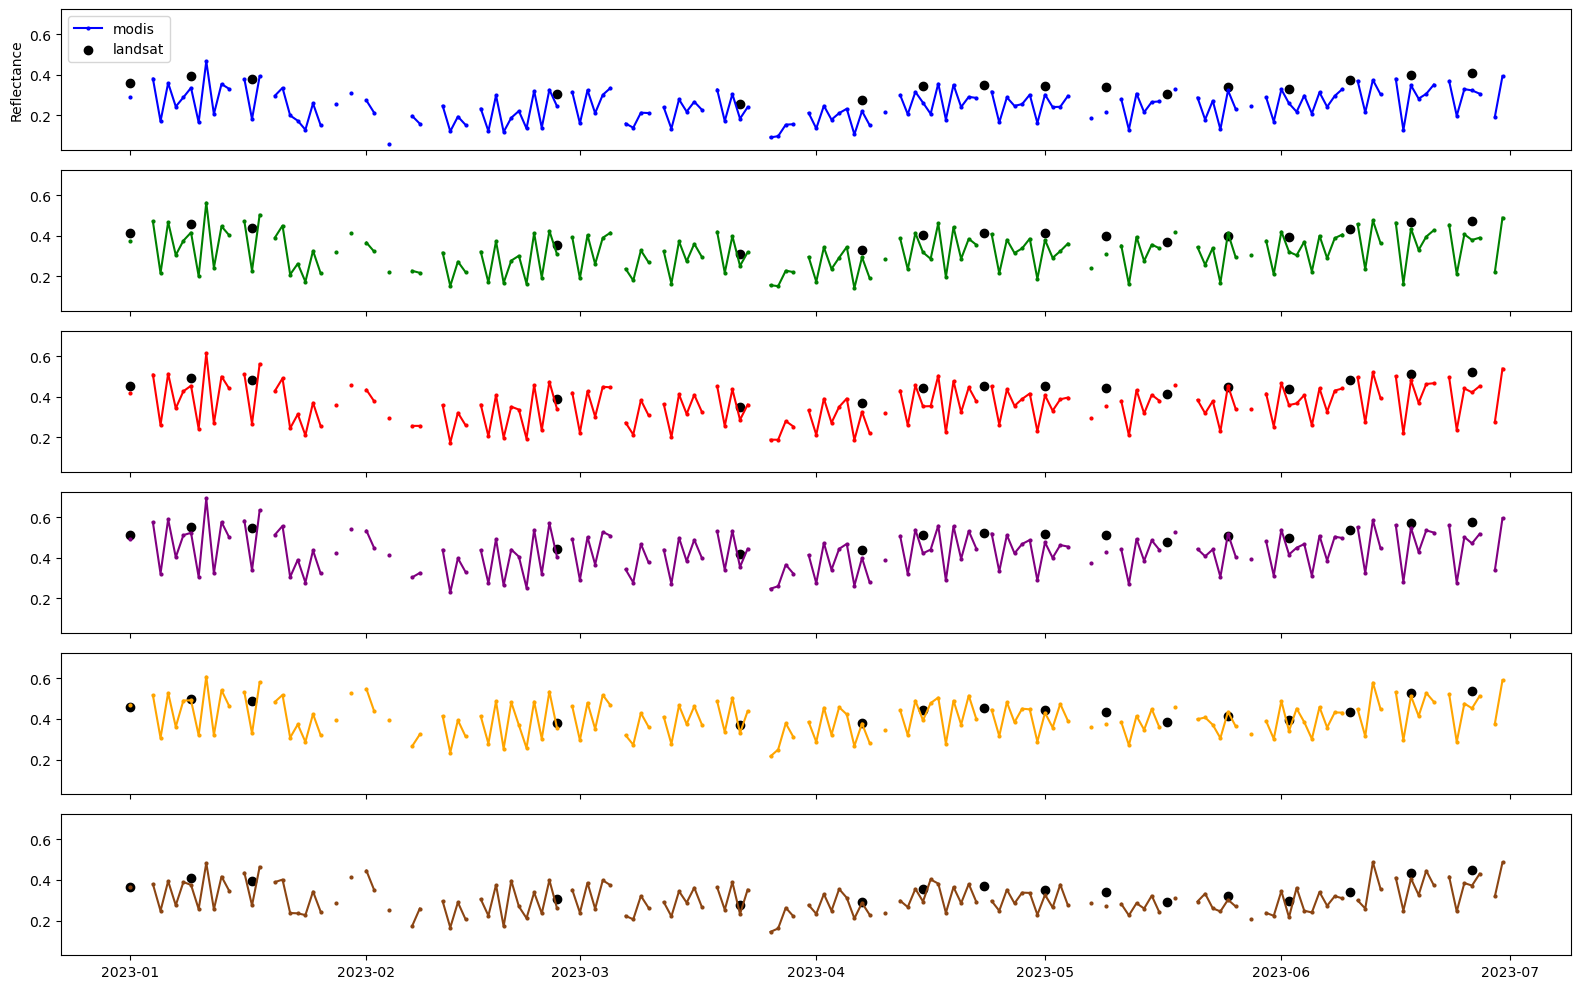

In [27]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(fused.index, fused['blue'], label='modis', c='blue', marker='o', markersize=2)
ax1.scatter(fused.index, fused['blue_mean'], label='landsat', color='black')
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(fused.index, fused['green'], c='green', marker='o', markersize=2)
ax2.scatter(fused.index, fused['green_mean'], color='black')

ax3.plot(fused.index, fused['red'], c='red', marker='o', markersize=2)
ax3.scatter(fused.index, fused['red_mean'], color='black')

ax4.plot(fused.index, fused['nir'], c='purple', marker='o', markersize=2)
ax4.scatter(fused.index, fused['nir_mean'], color='black')

ax5.plot(fused.index, fused['swir1'], c='orange', marker='o', markersize=2)
ax5.scatter(fused.index, fused['swir1_mean'], color='black')

ax6.plot(fused.index, fused['swir2'], c='saddlebrown', marker='o', markersize=2)
ax6.scatter(fused.index, fused['swir2_mean'], color='black')

plt.tight_layout()
plt.show()

Training blue with 375 coincident points.
Metrics blue - R2: 0.63 | MAE: 0.03 | RMSE: 0.05


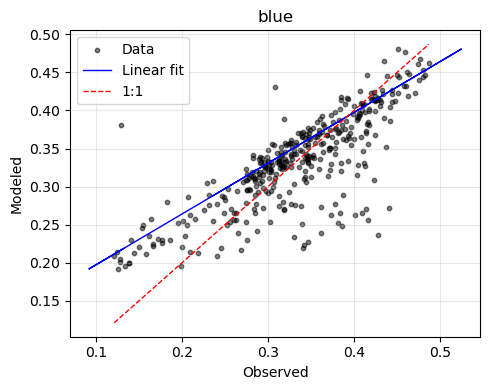

Training green with 377 coincident points.
Metrics green - R2: 0.61 | MAE: 0.04 | RMSE: 0.05


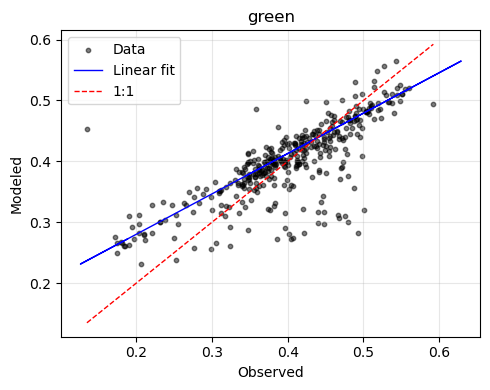

Training red with 354 coincident points.
Metrics red - R2: 0.58 | MAE: 0.04 | RMSE: 0.06


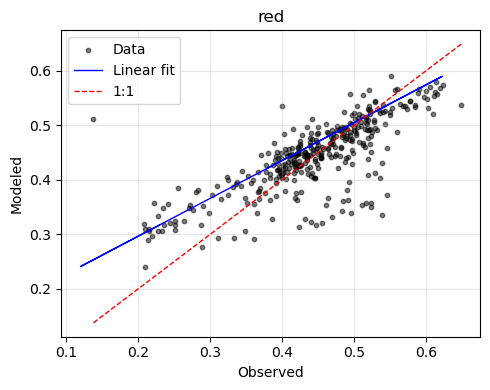

Training nir with 386 coincident points.
Metrics nir - R2: 0.60 | MAE: 0.04 | RMSE: 0.05


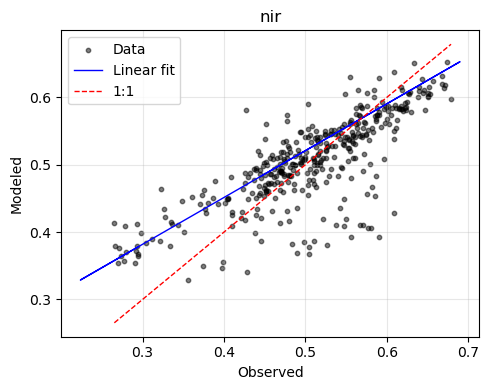

Training swir1 with 387 coincident points.
Metrics swir1 - R2: 0.64 | MAE: 0.04 | RMSE: 0.06


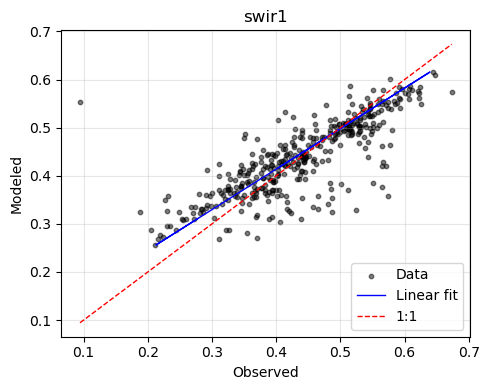

Training swir2 with 387 coincident points.
Metrics swir2 - R2: 0.81 | MAE: 0.03 | RMSE: 0.05


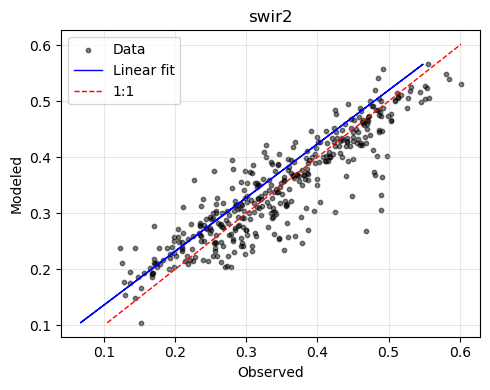

                blue     green       red       nir     swir1     swir2
2000-03-01  0.283702  0.355677  0.410334  0.473410  0.427441  0.327798
2000-03-02  0.233065  0.293201  0.341265  0.403954  0.363925  0.291182
2000-03-03  0.273428  0.344999  0.399852  0.468334  0.389871  0.331536
2000-03-04  0.264755  0.319863  0.357856  0.414939  0.360724  0.280351
2000-03-05  0.266423  0.328485  0.381873  0.443862  0.404360  0.333645


In [28]:
def generate_daily_landsat_series(df_landsat, df_modis, band_mapping):
    """
    Trains a linear relationship between Landsat and MODIS for specified bands
    using coincident valid observations, and predicts a continuous daily Landsat series.
    """
    
    # 1. Define the continuous daily timeline based on MODIS data extent
    start_date = df_modis.index.min()
    end_date = df_modis.index.max()
    daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # 2. Initialize the empty output DataFrame with the daily DatetimeIndex
    df_predicted_landsat = pd.DataFrame(index=daily_index)
    
    # 3. Loop through each band defined in the mapping dictionary
    for output_band_name, (landsat_col, modis_col) in band_mapping.items():
        
        # Check if columns exist to prevent KeyError
        if landsat_col not in df_landsat.columns or modis_col not in df_modis.columns:
            print(f"Warning: Columns for {output_band_name} not found. Skipping.")
            continue
            
        # Extract the individual 1D series for the current band
        s_landsat = df_landsat[landsat_col]
        s_modis = df_modis[modis_col]
        
        # 4. Extract coincident indices by aligning series by their DatetimeIndex
        df_aligned = pd.concat([s_landsat, s_modis], axis=1, keys=['landsat', 'modis'])
        df_coincident = df_aligned.dropna()
        
        if df_coincident.empty:
            print(f"Warning: No valid coincident dates found for {output_band_name}. Skipping.")
            continue
            
        print(f"Training {output_band_name} with {len(df_coincident)} coincident points.")
        
        # 5. Prepare training matrices for Scikit-Learn
        X_train = df_coincident[['modis']].values
        y_train = df_coincident['landsat'].values
        
        # 6. Train the Linear Regression model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # 7. Plot observed vs modeled values
        y_train_pred = model.predict(X_train)

        r2 = r2_score(y_train, y_train_pred)
        mae = mean_absolute_error(y_train, y_train_pred)
        rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        print(f"Metrics {output_band_name} - R2: {r2:.2f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
        
        plt.figure(figsize=(5, 4))
        plt.scatter(y_train, y_train_pred, alpha=0.5, color='black', label='Data', s=10)
        
        plt.plot(X_train, y_train_pred, color='blue', linewidth=1, label='Linear fit')

        min_val = min(y_train.min(), y_train_pred.min())
        max_val = max(y_train.max(), y_train_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1, label='1:1')
        
        plt.title(f'{output_band_name}')
        plt.xlabel('Observed')
        plt.ylabel('Modeled')
        plt.legend()
        plt.grid(True, linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 8. Prepare the continuous MODIS predictor data
        s_modis_daily = s_modis.reindex(daily_index)
        s_modis_clean = s_modis_daily.interpolate(method='time').bfill().ffill()
        
        X_predict = s_modis_clean.values.reshape(-1, 1)
        
        # 9. Predict the missing Landsat values
        y_predict = model.predict(X_predict)
        
        # 10. Store the predicted array in the output DataFrame
        df_predicted_landsat[output_band_name] = y_predict
        
    # Return the fully populated daily DataFrame
    return df_predicted_landsat

# Format -> 'Final Output Name': ('Landsat_Column_Name', 'MODIS_Column_Name')
band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

landsat_daily_df1 = generate_daily_landsat_series(landsat_df1, terra_df1, band_mapping) # entrenado con datos no suavizados
print(landsat_daily_df1.head())

In [29]:
landsat_daily_df1 = slice_by_dates(landsat_daily_df1, start, end)

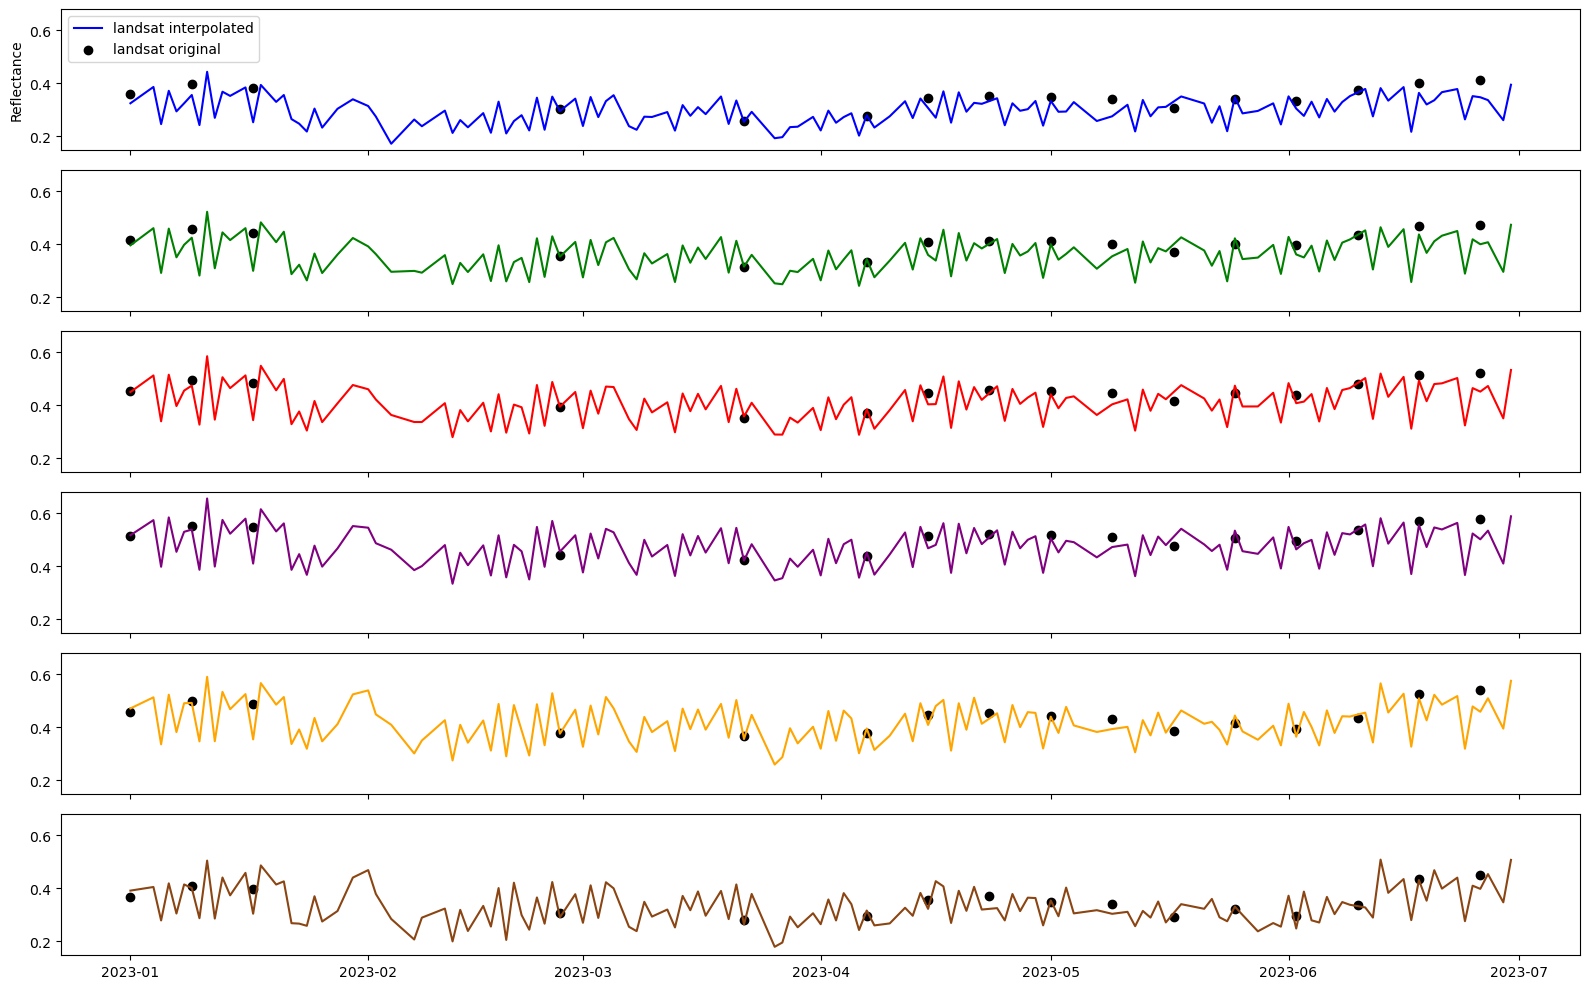

In [30]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 10), sharex=True, sharey=True)

ax1.plot(landsat_daily_df1.index, landsat_daily_df1['blue'], label='landsat interpolated', c='blue')
ax1.scatter(fused.index, fused['blue_mean'], label='landsat original', color='black')
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')

ax2.plot(landsat_daily_df1.index, landsat_daily_df1['green'], c='green')
ax2.scatter(fused.index, fused['green_mean'], color='black')

ax3.plot(landsat_daily_df1.index, landsat_daily_df1['red'], c='red')
ax3.scatter(fused.index, fused['red_mean'], color='black')

ax4.plot(landsat_daily_df1.index, landsat_daily_df1['nir'], c='purple')
ax4.scatter(fused.index, fused['nir_mean'], color='black')

ax5.plot(landsat_daily_df1.index, landsat_daily_df1['swir1'], c='orange')
ax5.scatter(fused.index, fused['swir1_mean'], color='black')

ax6.plot(landsat_daily_df1.index, landsat_daily_df1['swir2'], c='saddlebrown')
ax6.scatter(fused.index, fused['swir2_mean'], color='black')

plt.tight_layout()
plt.show()